In [1]:
import pandas as pd

# Charger les features déjà calculées
user_volume = pd.read_csv("../data/processed/user_volume_recency.csv")
category_entropy = pd.read_csv("../data/processed/user_category_entropy.csv")
user_style = pd.read_csv("../data/processed/user_style_features.csv")
user_temporal = pd.read_csv("../data/processed/user_temporal_features.csv")

# Sécuriser user_id
for df_ in [user_volume, category_entropy, user_style, user_temporal]:
    df_["user_id"] = df_["user_id"].astype(str).str.strip()

# Fusion finale
user_behavior = (
    user_volume
    .merge(category_entropy, on="user_id", how="left")
    .merge(user_style, on="user_id", how="left")
    .merge(user_temporal, on="user_id", how="left")
)

user_behavior.head()


,user_id,nb_interactions,nb_products,recency_days,favorite_category,favorite_category_share,category_entropy,avg_rating,rating_std,avg_review_length,avg_sentiment,weekend_activity_ratio
0,AE225Z2VRWT6GPTOMA4H4O3H2KVQ,1,1,1840,Digital_Music,1.0,-0.0,0.557747,NaN,17.000000,0.416667,1.000000
1,AE23YCERVBZ7ABKTESKSSXYTLYRA,1,1,4840,Digital_Music,1.0,-0.0,0.557747,NaN,59.000000,0.251389,0.000000
2,AE246WPAV4HBLUOOOKTECTYQ7ZPA,2,2,1,Cell_Phones_and_Accessories,1.0,-0.0,0.557747,0.000000,40.500000,0.240655,0.000000
3,AE25NQAZI3725GZIL5FS52ZIKWKQ,9,9,1219,Automotive,1.0,-0.0,0.158272,1.198424,9.333333,0.439947,0.333333
4,AE26ICWKMFJEHDH5VDX4W42H2NMA,3,3,596,Electronics,1.0,-0.0,-0.041465,0.518933,18.666667,0.184028,0.000000


In [2]:
user_behavior.shape
user_behavior.columns.tolist()


['user_id',
 'nb_interactions',
 'nb_products',
 'recency_days',
 'favorite_category',
 'favorite_category_share',
 'category_entropy',
 'avg_rating',
 'rating_std',
 'avg_review_length',
 'avg_sentiment',
 'weekend_activity_ratio']

In [4]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# On garde uniquement les variables numériques
cluster_features = user_behavior.select_dtypes(include=[np.number])

# Sécurité : pas de NaN
cluster_features = cluster_features.fillna(0)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_features)

X_scaled.shape



(3777, 10)

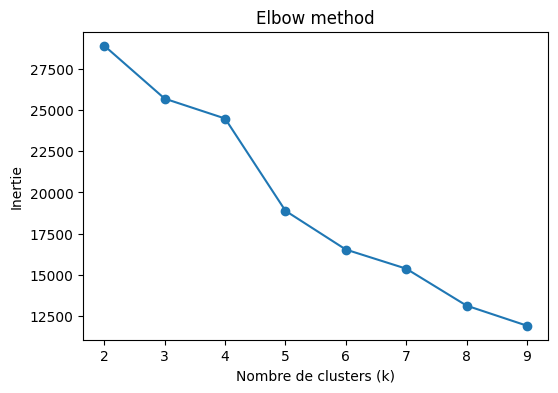

In [5]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
K = range(2, 10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertias, marker="o")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie")
plt.title("Elbow method")
plt.show()


In [6]:
from sklearn.metrics import silhouette_score

for k in range(2, 8):
    labels = KMeans(n_clusters=k, random_state=42).fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k} → silhouette={score:.3f}")


k=2 → silhouette=0.378
k=3 → silhouette=0.348
k=4 → silhouette=0.310
k=5 → silhouette=0.339
k=6 → silhouette=0.286
k=7 → silhouette=0.308


In [7]:
kmeans = KMeans(n_clusters=4, random_state=42)
user_behavior["cluster"] = kmeans.fit_predict(X_scaled)

user_behavior["cluster"].value_counts()


cluster
1    2512
0     490
3     391
2     384
Name: count, dtype: int64

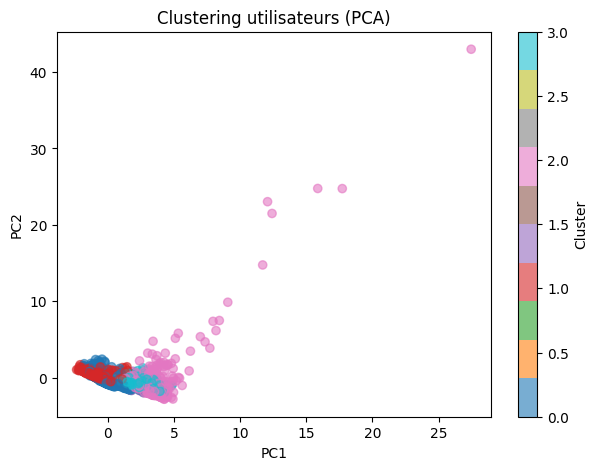

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=user_behavior["cluster"],
    cmap="tab10",
    alpha=0.6
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clustering utilisateurs (PCA)")
plt.colorbar(label="Cluster")
plt.show()


In [9]:
cluster_summary = (
    user_behavior
    .groupby("cluster")[cluster_features.columns]
    .mean()
    .round(2)
)

cluster_summary


,nb_interactions,nb_products,recency_days,favorite_category_share,category_entropy,avg_rating,rating_std,avg_review_length,avg_sentiment,weekend_activity_ratio
cluster,,,,,,,,,,
0,2.15,2.15,1900.97,1.00,0.01,-1.48,1.29,89.94,0.11,0.30
1,1.81,1.81,2026.89,1.00,0.01,0.45,0.23,30.58,0.42,0.27
2,31.86,31.86,447.45,0.63,1.13,-0.61,1.41,45.18,0.24,0.29
3,8.10,8.10,654.18,0.57,1.21,0.32,0.37,29.68,0.39,0.28


In [10]:
reviews = pd.read_csv("../data/processed/amazon_reviews_cleaned.csv")

# sécuriser
reviews["user_id"] = reviews["user_id"].astype(str)
user_behavior["user_id"] = user_behavior["user_id"].astype(str)

# rattacher chaque review à un cluster
reviews = reviews.merge(
    user_behavior[["user_id", "cluster"]],
    on="user_id",
    how="left"
)


In [11]:
cluster_products = (
    reviews
    .groupby(["cluster", "asin"])
    .agg(
        avg_rating=("rating", "mean"),
        nb_reviews=("rating", "count")
    )
    .reset_index()
)

# score simple
cluster_products["score"] = cluster_products["avg_rating"] * np.log1p(cluster_products["nb_reviews"])


In [12]:
def recommend_for_user(user_id, top_n=5):
    user_cluster = user_behavior.loc[
        user_behavior["user_id"] == user_id, "cluster"
    ].values[0]

    seen = set(
        reviews.loc[reviews["user_id"] == user_id, "asin"]
    )

    candidates = (
        cluster_products[cluster_products["cluster"] == user_cluster]
        .sort_values("score", ascending=False)
    )

    recs = candidates[~candidates["asin"].isin(seen)].head(top_n)
    return recs

recommend_for_user(user_behavior["user_id"].iloc[0])


,cluster,asin,avg_rating,nb_reviews,score
1373,1,B0000041CD,4.875000,8,10.711470
2331,1,B001EJH4SW,4.875000,8,10.711470
3897,1,B014QI0FI8,4.857143,7,10.100145
3138,1,B00A44I5M2,4.857143,7,10.100145
1279,1,5559166928,5.000000,6,9.729551


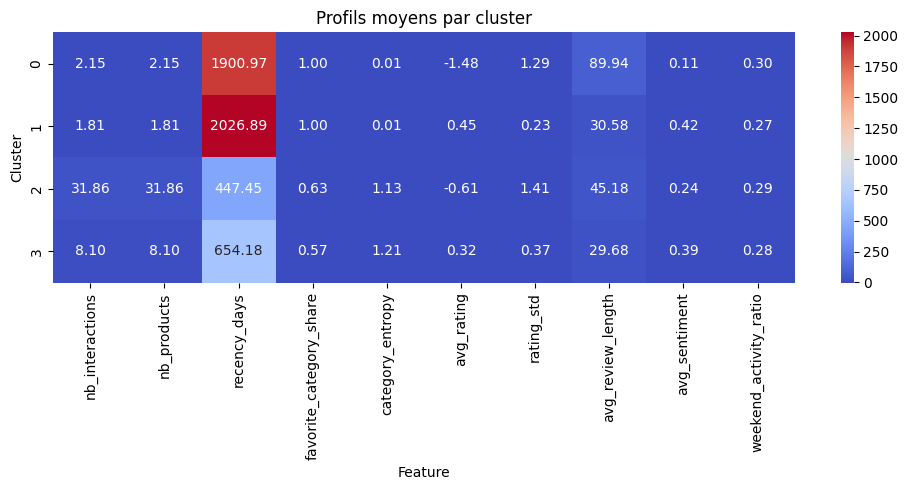

In [16]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Supposez user_behavior et cluster_features déjà définis comme dans votre notebook
cluster_summary = (
    user_behavior
    .groupby("cluster")[cluster_features.columns]
    .mean()
    .round(2)
)

plt.figure(figsize=(10, 5))
sns.heatmap(cluster_summary, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Profils moyens par cluster")
plt.ylabel("Cluster")
plt.xlabel("Feature")
plt.tight_layout()
plt.show()

favorite_category  Automotive  Books  CDs_and_Vinyl  \
cluster                                               
0                          43     13             26   
1                         154     43            205   
2                          73     45             19   
3                         100     70             32   

favorite_category  Cell_Phones_and_Accessories  Clothing_Shoes_and_Jewelry  \
cluster                                                                      
0                                           72                          12   
1                                          167                          24   
2                                           97                          84   
3                                           86                          43   

favorite_category  Digital_Music  Electronics  
cluster                                        
0                            306           18  
1                           1884           35  
2       

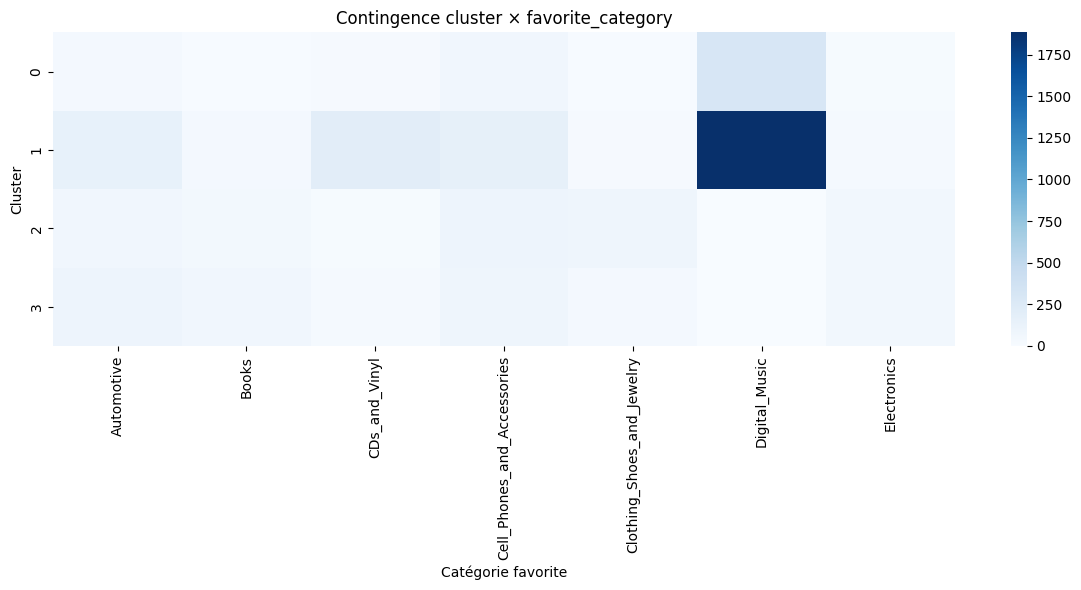

In [17]:
ct = pd.crosstab(user_behavior["cluster"], user_behavior["favorite_category"])
print(ct)

plt.figure(figsize=(12, 6))
sns.heatmap(ct, cmap="Blues", annot=False)
plt.title("Contingence cluster × favorite_category")
plt.ylabel("Cluster")
plt.xlabel("Catégorie favorite")
plt.tight_layout()
plt.show()

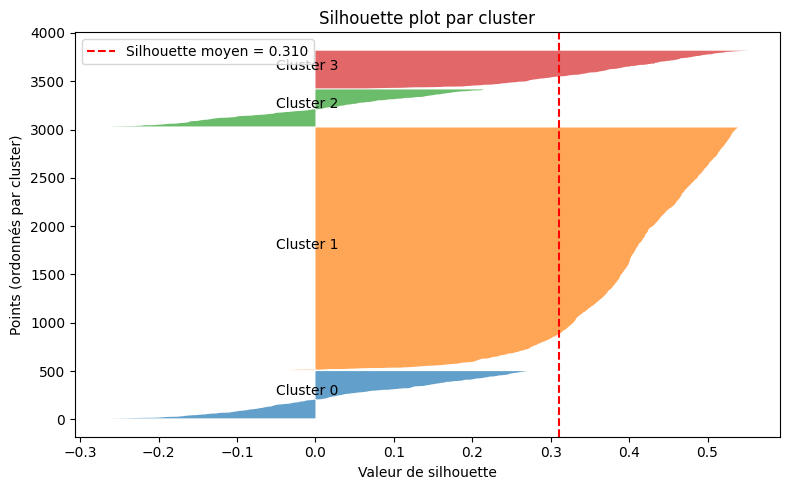

In [19]:
from sklearn.metrics import silhouette_samples, silhouette_score

X = X_scaled
labels = user_behavior["cluster"].values
sil_vals = silhouette_samples(X, labels)
sil_avg = silhouette_score(X, labels)

plt.figure(figsize=(8, 5))
y_lower = 10
for c in sorted(np.unique(labels)):
    c_sil_vals = sil_vals[labels == c]
    c_sil_vals.sort()
    size_c = c_sil_vals.shape[0]
    y_upper = y_lower + size_c
    color = plt.cm.tab10(c % 10)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil_vals, facecolor=color, alpha=0.7)
    plt.text(-0.05, (y_lower + y_upper) / 2, f"Cluster {c}")
    y_lower = y_upper + 10  # gap

plt.axvline(sil_avg, color="red", linestyle="--", label=f"Silhouette moyen = {sil_avg:.3f}")
plt.xlabel("Valeur de silhouette")
plt.ylabel("Points (ordonnés par cluster)")
plt.title("Silhouette plot par cluster")
plt.legend()
plt.tight_layout()
plt.show()

col_0    0     1    2    3  4
row_0                        
0      356     7  125    2  0
1       75  2415   22    0  0
2        1     0  170  207  6
3        0    10    3  378  0


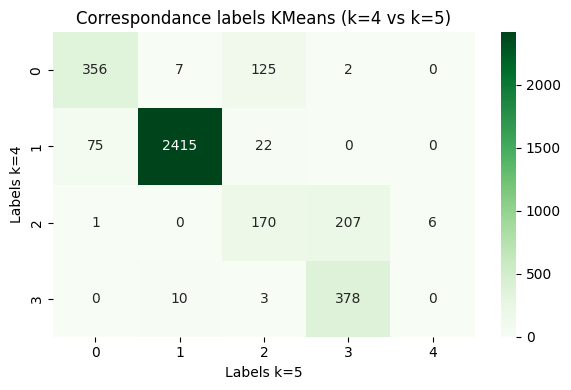

In [22]:
from sklearn.cluster import KMeans

kmeans4 = KMeans(n_clusters=4, random_state=42).fit(X_scaled)
kmeans5 = KMeans(n_clusters=5, random_state=42).fit(X_scaled)

labels4 = kmeans4.labels_
labels5 = kmeans5.labels_

corr = pd.crosstab(labels4, labels5)
print(corr)

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt="d", cmap="Greens")
plt.title("Correspondance labels KMeans (k=4 vs k=5)")
plt.xlabel("Labels k=5")
plt.ylabel("Labels k=4")
plt.tight_layout()
plt.show()

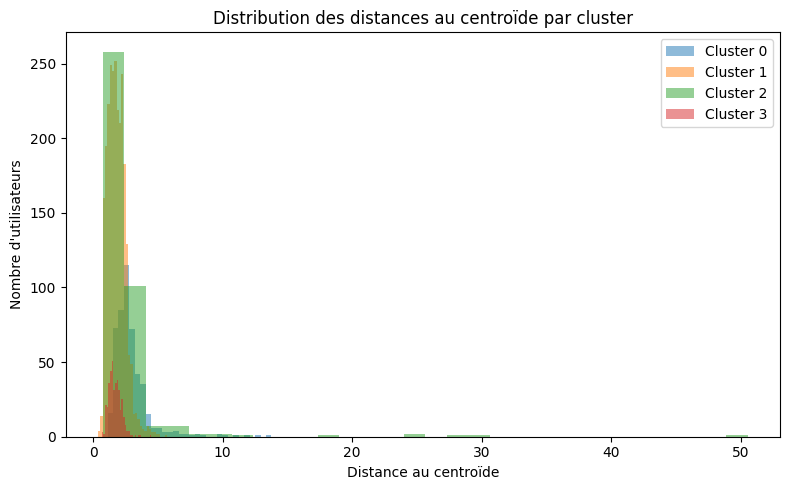

                           user_id  cluster  dist_to_centroid
1885  AFZUK3MTBIBEDQOPAK3OATUOUKLA        2         50.496564
3620  AHV6QCNBJNSGLATP56JAWJ3C4G2A        2         29.347660
1779  AFW2PDT3AMT4X3PYQG7FJZH5FXFA        2         28.330094
1917  AG3S4FROO422V5KP7DJCBXVUQLJQ        2         25.233137
154   AE7BV6IMNPZ3F266H7PXMH3BZQNQ        2         24.269562
1406  AFJBKPK5W56XWSNPQU2WW66ISWYQ        2         17.460808
1745  AFUZG4S57VOZIENQ5LJHBPEO5T2Q        0         13.767479
350   AEGVEWWGTQO3PK3JF5NYB7GSSSVQ        0         12.761503
1679  AFSKPY37N3C43SOI5IEXEK5JSIYA        2         11.874952
3424  AHOHZTCL3LM46MJ22CF5IXBFHKEA        0         11.868092


In [23]:
# filename: distance_to_centroids.py

from sklearn.metrics import pairwise_distances_argmin_min

# Réutiliser le modèle KMeans déjà fit (kmeans)
centroids = kmeans.cluster_centers_
closest, distances = pairwise_distances_argmin_min(X_scaled, centroids)

user_behavior["dist_to_centroid"] = distances

plt.figure(figsize=(8,5))
for c in sorted(user_behavior["cluster"].unique()):
    d = user_behavior.loc[user_behavior["cluster"] == c, "dist_to_centroid"]
    plt.hist(d, bins=30, alpha=0.5, label=f"Cluster {c}")
plt.xlabel("Distance au centroïde")
plt.ylabel("Nombre d'utilisateurs")
plt.title("Distribution des distances au centroïde par cluster")
plt.legend()
plt.tight_layout()
plt.show()

# Quelques outliers potentiels
print(user_behavior.sort_values("dist_to_centroid", ascending=False).head(10)[["user_id","cluster","dist_to_centroid"]])


In [24]:
# filename: extra_indices.py
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score

labels = user_behavior["cluster"].values
dbi = davies_bouldin_score(X_scaled, labels)  # plus petit = meilleur
ch = calinski_harabasz_score(X_scaled, labels)  # plus grand = meilleur

print(f"Davies-Bouldin Index: {dbi:.3f}")
print(f"Calinski-Harabasz Score: {ch:.1f}")


Davies-Bouldin Index: 1.731
Calinski-Harabasz Score: 681.9


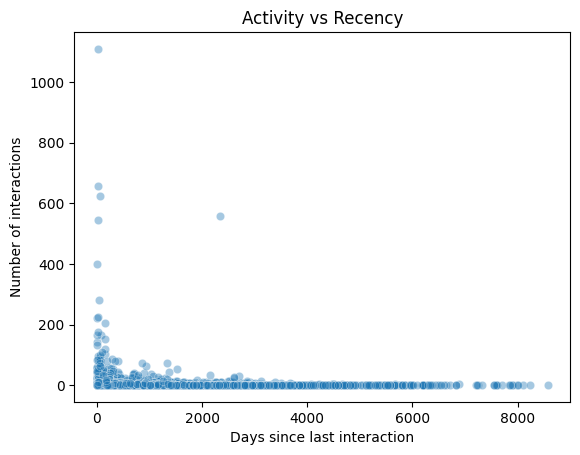

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=user_behavior,
    x="recency_days",
    y="nb_interactions",
    alpha=0.4
)
plt.title("Activity vs Recency")
plt.xlabel("Days since last interaction")
plt.ylabel("Number of interactions")
plt.show()


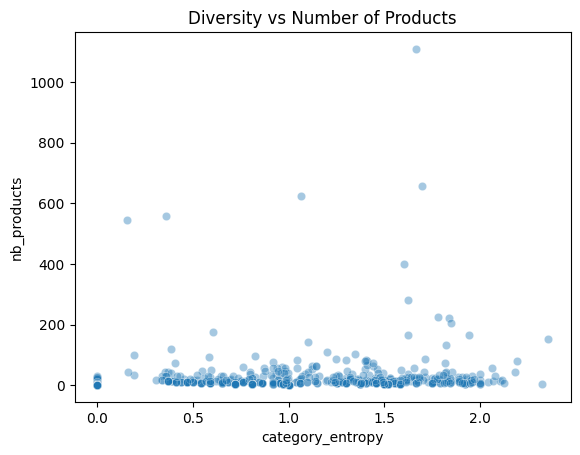

In [26]:
sns.scatterplot(
    data=user_behavior,
    x="category_entropy",
    y="nb_products",
    alpha=0.4
)
plt.title("Diversity vs Number of Products")
plt.show()


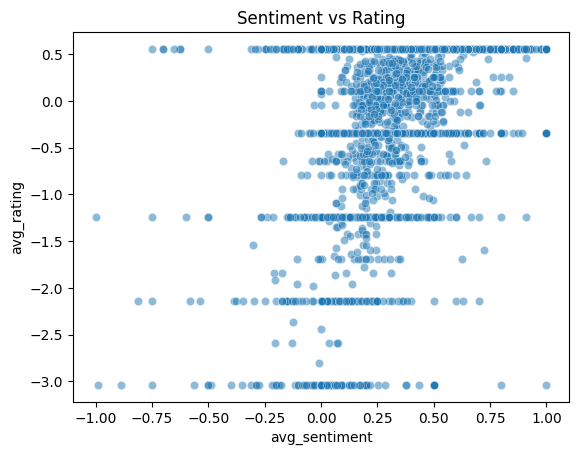

In [27]:
sns.scatterplot(
    data=user_behavior,
    x="avg_sentiment",
    y="avg_rating",
    alpha=0.5
)
plt.title("Sentiment vs Rating")
plt.show()
